# Task
Train a Linear Regression model on the California Housing dataset, evaluate its performance using MAE and RMSE, visualize predictions against actual values, and interpret the model coefficients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.rename(columns={'MedHouseVal': 'MedHouseVal'}, inplace=True)
print("California Housing dataset loaded and converted to DataFrame.")
print(df.head())

California Housing dataset loaded and converted to DataFrame.
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())
print("\nDisplaying concise summary of the DataFrame:")
df.info()
print("\nDisplaying descriptive statistics of the DataFrame:")
print(df.describe())

Displaying the first 5 rows of the DataFrame:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Displaying concise summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   Av

In [4]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print("Features (X) and Target (y) separated.")
print("X head:\n", X.head())
print("y head:\n", y.head())

Features (X) and Target (y) separated.
X head:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
y head:
 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model initialized and trained successfully.")

Linear Regression model initialized and trained successfully.


In [7]:
y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Comparison of Actual vs. Predicted values (first 20 samples):")
print(comparison_df.head(20))

Comparison of Actual vs. Predicted values (first 20 samples):
        Actual  Predicted
20046  0.47700   0.719123
3024   0.45800   1.764017
15663  5.00001   2.709659
20484  2.18600   2.838926
9814   2.78000   2.604657
13311  1.58700   2.011754
7113   1.98200   2.645500
7668   1.57500   2.168755
18246  3.40000   2.740746
5723   4.46600   3.915615
20069  1.23200   0.938962
6835   2.53900   1.901222
11351  2.15100   1.758712
20267  2.20500   2.250160
7097   2.19800   2.540870
6298   1.36200   1.917405
696    1.78400   2.386483
19607  1.87500   2.010930
14173  1.39800   2.227409
19638  1.37500   1.118532


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456


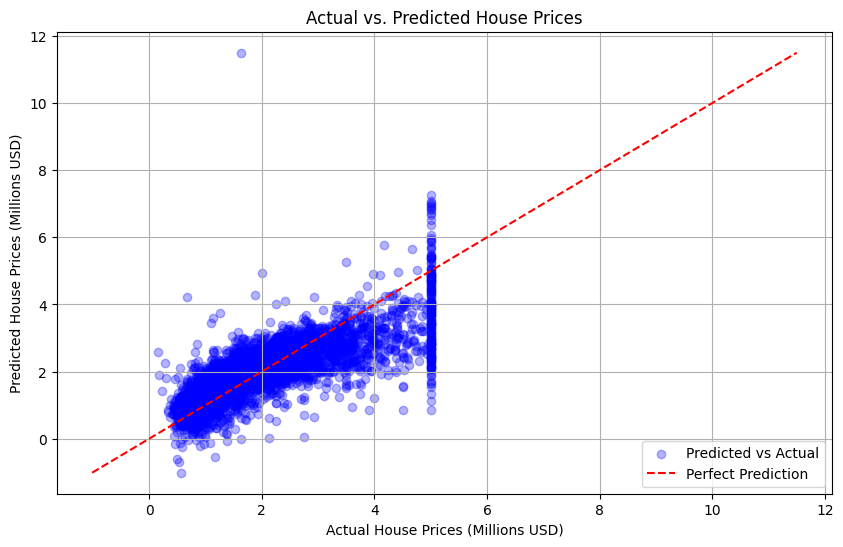

Scatter plot of Actual vs. Predicted House Prices generated successfully.


In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', label='Predicted vs Actual')

# Add a diagonal line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual House Prices (Millions USD)')
plt.ylabel('Predicted House Prices (Millions USD)')
plt.legend()
plt.grid(True)
plt.show()

print("Scatter plot of Actual vs. Predicted House Prices generated successfully.")

In [10]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("Model Coefficients:")
print(coefficients)

Model Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708
